# Extractors Head to Head

**GLiNER2.5 vs Claude vs spaCy vs escalation, on one corpus, one ontology, one scoreboard.**

Notebooks [01](01_gliner25_knowledge_graphs.ipynb) and [02](02_neo4j_graphrag_retrieval.ipynb) demonstrate
one extractor thoroughly and compare it to nothing. Every claim about where GLiNER2.5 wins and loses is
argued from architecture rather than measured — including the central one, that a span-based model *cannot*
recover facts requiring inference.

This notebook measures it. Four pipelines, the same ten documents, the same `BUSINESS_NEWS` ontology, scored
against the 47 gold triples that have been sitting unused in `kgx.data.documents` since the corpus was
written.

| | what it is | open vocab | relations | unanchored arguments | cost |
|---|---|---|---|---|---|
| **spaCy `en_core_web_trf`** | supervised, 18 fixed labels | ✗ | ✗ | ✗ | free |
| **GLiNER2.5-base** | 194M zero-shot encoder, joint decoding | ✓ | ✓ | ✗ | free |
| **Claude Haiku 4.5** | frontier LLM, structured output | ✓ | ✓ | ✗ | per token |
| **Escalation** | GLiNER everywhere, Claude on hard chunks | ✓ | ✓ | ✗ | tunable |

That fourth column used to read *implicit facts*, with a ✗ against the encoder and a ✓ against the LLM. §3
runs the probes that claim was built on and neither half survives: relations get inferred by both, and an
entity argument that appears nowhere in the text is recovered by neither. The column now names the boundary
the probes actually support, which is why nothing scores in it. §6 states the corrected version.

### No API key needed

The LLM runs through the `claude` CLI, which is already installed and authenticated if you use Claude Code.
Every response is cached to `output/llm_cache/`, so a re-run *on this machine* costs nothing and returns
byte-identical results.

`output/` is gitignored, so the cache does not travel with the repo. On a fresh clone the first run is 17
live calls — ten documents plus the seven probes in §3, for the sub-dime total §6 prints — and the triples
that come back will not be the ones scored here: the CLI exposes no temperature or seed, and `--model haiku`
is a moving alias that resolves to whatever Haiku the installed CLI points at, which is also why every row
below says "Claude Haiku 4.5" with no build behind it. Expect the LLM's numbers to move by a few points —
they moved while this notebook was being written. GLiNER and spaCy produce the same extractions every run;
only their wall-clock timings wander.

In [1]:
import os, sys, time, json, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 48)

import kgx
from kgx.data.documents import DOCUMENTS, GOLD_DOC_FACTS, ALIAS_GROUPS
from kgx.evaluate import score_triples, graph_triples, comparison_table, MatchPolicy
from kgx.llm import ClaudeCLI, LLMExtractor
from kgx.baselines import SpacyExtractor, ONTONOTES_TO_BUSINESS_NEWS

print(f"corpus     {len(DOCUMENTS)} documents, {sum(len(d['text'].split()) for d in DOCUMENTS)} words")
print(f"ontology   {len(kgx.BUSINESS_NEWS.entities)} entity types, {len(kgx.BUSINESS_NEWS.relations)} relations")
print(f"gold       {len(GOLD_DOC_FACTS)} triples, {len(ALIAS_GROUPS)} alias groups")

corpus     10 documents, 2284 words
ontology   13 entity types, 15 relations
gold       47 triples, 13 alias groups


## 0. What "the same triple" means

Before any number, the measurement policy — because triple scoring is mostly a definition problem and the
definition decides the result.

`("Northwind Logistics Inc.", "acquires", "Cascade Freight Systems")` and
`("Northwind Logistics Inc", "acquires", "Cascade")` are the same fact. An evaluator that calls them
different is measuring string formatting. So:

- **Relations must match exactly** — closed vocabulary, no fuzz.
- **Names match after normalisation** — the same `kgx.resolve.normalize` used during entity resolution.
- **Names match through the corpus alias table** — `Cascade` counts as `Cascade Freight Systems`.
- **Matching is one-to-one** — one prediction cannot satisfy two gold triples.

Both a strict and a lenient policy are reported. Where a comparison flips between them, that is a finding
about the comparison, not a detail to bury.

In [2]:
STRICT  = MatchPolicy(normalize_names=True, use_aliases=False)
LENIENT = MatchPolicy(normalize_names=True, use_aliases=True)

demo = [("Northwind Logistics Inc", "acquires", "Cascade"),          # alias on both sides
        ("Northwind", "partners_with", "Securities and Exchange Commission")]  # not in gold

for policy in (STRICT, LENIENT):
    s = score_triples(demo, GOLD_DOC_FACTS, policy=policy, aliases=ALIAS_GROUPS)
    print(f"  {policy.label:22} matched {len(s.matched)}/2 predicted")

  strict                 matched 0/2 predicted
  normalised + aliases   matched 1/2 predicted


## 1. The four pipelines

Each returns the same `DocGraph` type, so everything downstream — resolution, graph building, scoring — is
byte-identical across systems. That interchangeability is the only thing that makes the comparison fair; if
each extractor got its own bespoke post-processing, the benchmark would be measuring the post-processing.

### spaCy — the closed-vocabulary floor

In [3]:
spacy_ex = SpacyExtractor("en_core_web_trf")
print(spacy_ex, "\n")

coverage = spacy_ex.coverage(kgx.BUSINESS_NEWS)
print(f"ontology entity types reachable : {coverage['reachable']}/{coverage['ontology_types']}")
print(f"ontology relations supported    : {coverage['relations_supported']}/{coverage['ontology_relations']}")
print(f"\nunreachable types  : {', '.join(coverage['unreachable'])}")
print(f"spaCy labels unused: {', '.join(coverage['spacy_labels_unused'])}")

<SpacyExtractor en_core_web_trf 18 labels ents_f=0.899> 

ontology entity types reachable : 5/13
ontology relations supported    : 0/15

unreachable types  : regulator, business_segment, sector, security, financial_metric, risk_factor, litigation, commodity
spaCy labels unused: CARDINAL, DATE, FAC, LANGUAGE, LAW, MONEY, NORP, ORDINAL, PERCENT, QUANTITY, TIME, WORK_OF_ART


That table is the result, before a single document is processed. spaCy's model card reports **0.899 F1 on
OntoNotes**, the benchmark it was trained for — entity accuracy on *this* corpus is never scored here — and
it can express **5 of 13** entity types and **0 of 15** relations in this ontology.

Both halves are true and neither is a criticism. If your types are PERSON / ORG / GPE, a supervised tagger is
the right answer and the rest of this notebook is irrelevant to you. The moment your types are
`risk_factor` and `business_segment`, no amount of F1 on OntoNotes helps.

In [4]:
t = time.time()
spacy_graphs = spacy_ex.extract_batch(DOCUMENTS, kgx.BUSINESS_NEWS)
spacy_time = time.time() - t
print(f"{len(DOCUMENTS)} documents in {spacy_time:.1f}s ({spacy_time/len(DOCUMENTS)*1000:.0f} ms/doc)")
print(f"{sum(len(g.mentions) for g in spacy_graphs)} mentions, "
      f"{sum(len(g.edges) for g in spacy_graphs)} relations")

10 documents in 0.6s (65 ms/doc)
189 mentions, 0 relations


### GLiNER2.5 — zero-shot, joint decoding

In [5]:
gliner_ex = kgx.GlinerExtractor()
print(gliner_ex)

t = time.time()
gliner_graphs = gliner_ex.extract_batch(DOCUMENTS, kgx.BUSINESS_NEWS)
gliner_time = time.time() - t
print(f"\n{len(DOCUMENTS)} documents in {gliner_time:.1f}s ({gliner_time/len(DOCUMENTS)*1000:.0f} ms/doc)")
print(f"{sum(len(g.mentions) for g in gliner_graphs)} mentions, "
      f"{sum(len(g.edges) for g in gliner_graphs)} relations")
print(f"ontology violations: {sum(len(g.validate(kgx.BUSINESS_NEWS)) for g in gliner_graphs)}")

<GlinerExtractor fastino/gliner2.5-base-v1 194M params loaded in 4.7s>



10 documents in 8.4s (837 ms/doc)
214 mentions, 170 relations
ontology violations: 0


### Claude — the same ontology, as a prompt

In [6]:
llm = ClaudeCLI(model="haiku")
print("claude CLI:", llm.check())
print(f"cache: {llm.cache_dir} ({len(list(llm.cache_dir.glob('*.json')))} responses)\n")

llm_ex = LLMExtractor(llm)

t = time.time()
llm_graphs = llm_ex.extract_batch(DOCUMENTS, kgx.BUSINESS_NEWS, workers=4)
llm_time = time.time() - t
print(f"{len(DOCUMENTS)} documents in {llm_time:.1f}s")
print(f"{sum(len(g.mentions) for g in llm_graphs)} mentions, "
      f"{sum(len(g.edges) for g in llm_graphs)} relations")
print(f"ontology violations: {sum(len(g.validate(kgx.BUSINESS_NEWS)) for g in llm_graphs)}")
print(f"\n{llm.stats()}")

# `llm` is shared with the §3 probes and its counters are cumulative, so snapshot
# the document-only figures here. §5 divides by these, not by the running totals.
doc_calls, doc_cost_usd, doc_latency_ms = llm.n_observed, llm.observed_cost_usd, llm.mean_latency_ms
print(f"documents only: {doc_calls} calls, ${doc_cost_usd:.4f}, {doc_latency_ms:.0f} ms mean latency")

claude CLI: 2.1.246 (Claude Code)
cache: output/llm_cache (36 responses)

10 documents in 0.0s
162 mentions, 140 relations
ontology violations: 16

{'model': 'haiku', 'live_calls': 0, 'cache_hits': 10, 'cost_usd_this_run': 0.0, 'cost_usd_observed': 0.0766, 'live_seconds': 0.0, 'mean_latency_ms': 6116}
documents only: 10 calls, $0.0766, 6116 ms mean latency


The ontology reaches the LLM as a prompt — the same `Ontology` object that compiles to GLiNER's
`JointSchema`, rendered as type names, descriptions and head/tail constraints. Worth noticing that this is
*all it is*: for the encoder the ontology is a decoding constraint the model cannot violate; for the LLM it
is a request the model may decline.

The violation counts above are that difference, measured.

In [7]:
violations = [(g.doc_id, v, g.mention(v.head).type, g.mention(v.tail).type)
              for g in llm_graphs for v in g.validate(kgx.BUSINESS_NEWS)]
if violations:
    print(f"{len(violations)} edges the LLM produced that the ontology forbids:\n")
    for doc_id, edge, htype, ttype in violations[:8]:
        g = next(x for x in llm_graphs if x.doc_id == doc_id)
        rel = kgx.BUSINESS_NEWS.relation(edge.type)
        print(f"  [{doc_id}] {g.mention(edge.head).text!r} ({htype}) "
              f"-{edge.type}-> {g.mention(edge.tail).text!r} ({ttype})")
        print(f"          declared: {'|'.join(rel.head)} -> {'|'.join(rel.tail)}")
else:
    print("no violations this run")
print("\nGLiNER's JointIE cannot produce these: typed endpoints are a hard decoding constraint,")
print("not a post-filter. With the LLM you either validate afterwards or carry the errors.")

16 edges the LLM produced that the ontology forbids:

  [d02] 'Surface Transportation Board' (regulator) -subject_to-> 'Northwind' (company)
          declared: company|product -> regulator
  [d02] 'Northwind' (company) -participant_in-> 'Cascade' (company)
          declared: company|person|regulator -> business_event
  [d02] 'Surface Transportation Board' (regulator) -participant_in-> 'Cascade' (company)
          declared: company|person|regulator -> business_event
  [d03] 'Dr. Elena Vasquez' (person) -officer_of-> 'Audit Committee' (business_segment)
          declared: person -> company|regulator
  [d03] 'Marcus Webb' (person) -officer_of-> 'Telematics' (business_segment)
          declared: person -> company|regulator
  [d03] 'Freight Brokerage' (business_segment) -faces_risk-> 'demand softening' (risk_factor)
          declared: company|sector -> risk_factor
  [d04] 'Freight Brokerage' (business_segment) -operates_in-> 'Northwind Logistics' (company)
          declared: company|

## 2. The scoreboard

Extraction is document-local; the gold facts are corpus-level and use canonical names. So each system's
output goes through the **same** entity-resolution and graph-building pipeline before scoring — otherwise
this would be measuring resolution, not extraction.

In [8]:
def build(graphs, label):
    """Resolve and assemble, identically for every system."""
    mentions = [m for g in graphs for m in g.mentions]
    resolver = kgx.EntityResolver(threshold=0.90).learn_aliases(d["text"] for d in DOCUMENTS)
    resolution = resolver.resolve(mentions)
    graph = kgx.build_graph(graphs, resolution, kgx.BUSINESS_NEWS)
    return {
        "label": label, "graph": graph,
        "mentions": len(mentions), "entities": len(graph.entities),
        "edges": len(graph.edges), "triples": graph_triples(graph),
    }

systems = {
    "spaCy trf (closed vocab)": build(spacy_graphs, "spacy"),
    "GLiNER2.5-base":           build(gliner_graphs, "gliner"),
    "Claude Haiku 4.5":         build(llm_graphs, "llm"),
}

display(pd.DataFrame([
    {"system": k, "mentions": v["mentions"], "canonical entities": v["entities"],
     "canonical edges": v["edges"]}
    for k, v in systems.items()
]).set_index("system"))

,mentions,canonical entities,canonical edges
system,,,
spaCy trf (closed vocab),189,59,0
GLiNER2.5-base,214,109,68
Claude Haiku 4.5,162,90,112


In [9]:
scores = {}
for name, sysinfo in systems.items():
    scores[name] = score_triples(sysinfo["triples"], GOLD_DOC_FACTS,
                                 policy=LENIENT, aliases=ALIAS_GROUPS)

display(comparison_table(scores))

,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
Claude Haiku 4.5,normalised + aliases,112,47,29,0.259,0.617,0.365
GLiNER2.5-base,normalised + aliases,68,47,19,0.279,0.404,0.330
spaCy trf (closed vocab),normalised + aliases,0,47,0,0.000,0.000,0.000


spaCy scores zero on triples, exactly as predicted — it produces no relations at all, so it cannot match a
single gold fact. It is in the table to keep the comparison honest, not because the number is in doubt.

§0 promised both policies, so here is the strict one. It is pure arithmetic over the triples already
computed: no model runs, no LLM spend.

In [10]:
strict_scores = {name: score_triples(sysinfo["triples"], GOLD_DOC_FACTS,
                                     policy=STRICT, aliases=ALIAS_GROUPS)
                 for name, sysinfo in systems.items()}
display(comparison_table(strict_scores))

moved = [n for n in scores
         if (len(scores[n].matched), scores[n].n_predicted)
         != (len(strict_scores[n].matched), strict_scores[n].n_predicted)]
print(f"lenient ordering: {' > '.join(comparison_table(scores).index)}")
print(f"strict  ordering: {' > '.join(comparison_table(strict_scores).index)}")
print(f"systems whose matched count changes when the alias table is removed: {moved or 'none'}")

,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
Claude Haiku 4.5,strict,112,47,28,0.250,0.596,0.352
GLiNER2.5-base,strict,68,47,19,0.279,0.404,0.330
spaCy trf (closed vocab),strict,0,47,0,0.000,0.000,0.000


lenient ordering: Claude Haiku 4.5 > GLiNER2.5-base > spaCy trf (closed vocab)
strict  ordering: Claude Haiku 4.5 > GLiNER2.5-base > spaCy trf (closed vocab)
systems whose matched count changes when the alias table is removed: ['Claude Haiku 4.5']


The ordering survives, and the alias table turns out to be worth one triple. GLiNER's row is identical under
both policies; Claude loses a single match. `normalize` already collapses the spellings these extractors
actually produce — *Northwind Logistics Inc* and *Northwind Logistics Inc.* have the same key with no table
involved — so the table only fires on the shortenings in §0's demo, where *Cascade* has to reach *Cascade
Freight Systems*. Worth knowing before treating the lenient
column as the generous one: on this corpus it is generous by one gold fact out of 47, and the comparison it
is being used to make does not depend on it.

The other correction the scoreboard needs is on the other side. §1 counted the ontology violations the LLM
produced, and those edges are still sitting inside the predictions being scored above — `build_graph`
canonicalises endpoints, it does not enforce the ontology. GLiNER gets that filter for free from typed
decoding. Price it for the LLM too.

In [11]:
import dataclasses

def drop_violations(graphs):
    """Same graphs, minus the edges whose endpoint types the ontology forbids."""
    out = []
    for g in graphs:
        illegal = {id(e) for e in g.validate(kgx.BUSINESS_NEWS)}
        out.append(dataclasses.replace(g, edges=[e for e in g.edges if id(e) not in illegal]))
    return out

llm_valid = drop_violations(llm_graphs)
valid_score = score_triples(build(llm_valid, "llm+validated")["triples"],
                            GOLD_DOC_FACTS, policy=LENIENT, aliases=ALIAS_GROUPS)
display(comparison_table({**scores, "Claude + ontology validation": valid_score}))

raw = sum(len(g.edges) for g in llm_graphs)
kept = sum(len(g.edges) for g in llm_valid)
before = scores["Claude Haiku 4.5"]
print(f"dropped {raw - kept} of {raw} document-local LLM edges "
      f"-> {before.n_predicted} to {valid_score.n_predicted} canonical triples")
print(f"  matched   {len(before.matched)} -> {len(valid_score.matched)}"
      f"    recall    {before.recall:.3f} -> {valid_score.recall:.3f}")
print(f"  precision {before.precision:.3f} -> {valid_score.precision:.3f}"
      f"    f1        {before.f1:.3f} -> {valid_score.f1:.3f}")

,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
Claude + ontology validation,normalised + aliases,96,47,29,0.302,0.617,0.406
Claude Haiku 4.5,normalised + aliases,112,47,29,0.259,0.617,0.365
GLiNER2.5-base,normalised + aliases,68,47,19,0.279,0.404,0.330
spaCy trf (closed vocab),normalised + aliases,0,47,0,0.000,0.000,0.000


dropped 16 of 140 document-local LLM edges -> 112 to 96 canonical triples
  matched   29 -> 29    recall    0.617 -> 0.617
  precision 0.259 -> 0.302    f1        0.365 -> 0.406


Validation costs nothing and it is not a rounding error. Every edge it removes was already spurious, so
recall does not move at all; precision and F1 each gain about four points. The plain Claude row is the
model's raw output and the validated row is what a pipeline would ship, and the distance between them is the
guarantee §1 measured, now with a price on it. GLiNER has no such row because it has nothing to drop — its
zero is the same filter, applied at decoding time rather than afterwards.

Everything downstream — §4's escalation sweep, §5's cost table, §6's final scoreboard — uses the unvalidated
LLM output, so read those as the floor for the LLM rather than its ceiling.

The interesting row is still the gap between the encoder and the LLM. Let me look at what each one actually
missed, because the aggregate hides the shape of it.

In [12]:
for name in ("GLiNER2.5-base", "Claude Haiku 4.5"):
    print(f"══ {name}")
    print(scores[name].report(limit=6))
    print()

══ GLiNER2.5-base
precision 0.279  recall 0.404  f1 0.330   (19/47 gold, 68 predicted, policy: normalised + aliases)

  missed (28):
    Northwind Logistics Inc. -has_stake_in-> Meridian Rail Group
    Northwind Logistics Inc. -supplies-> Halcyon Semiconductor Corporation
    Torrent Microsystems -supplies-> Northwind Logistics Inc.
    Vantage Energy Partners -supplies-> Northwind Logistics Inc.
    Vantage Energy Partners -supplies-> Halcyon Semiconductor Corporation
    Northwind Logistics Inc. -operates_in-> Seattle

  spurious (49):
    Cascade Freight Systems -competes_with-> Northwind Logistics Inc
    Northwind Logistics Inc -participant_in-> acquisition
    Northwind Logistics Inc -participant_in-> transaction
    Northwind Logistics Inc -participant_in-> agreement
    Northwind Logistics Inc -partners_with-> Cascade Freight Systems
    Cascade Freight Systems -reports_metric-> revenue

══ Claude Haiku 4.5
precision 0.259  recall 0.617  f1 0.365   (29/47 gold, 112 predicted, p

### Where the two disagree

In [13]:
gliner_hits = {(h.lower(), r, t.lower()) for _, (h, r, t) in
               [(p, g) for p, g in scores["GLiNER2.5-base"].matched]}
llm_hits    = {(h.lower(), r, t.lower()) for _, (h, r, t) in
               [(p, g) for p, g in scores["Claude Haiku 4.5"].matched]}

both     = gliner_hits & llm_hits
only_gl  = gliner_hits - llm_hits
only_llm = llm_hits - gliner_hits
neither  = {(h.lower(), r, t.lower()) for h, r, t in GOLD_DOC_FACTS} - gliner_hits - llm_hits

print(f"  both found        {len(both):3}")
print(f"  GLiNER only       {len(only_gl):3}")
print(f"  Claude only       {len(only_llm):3}")
print(f"  neither           {len(neither):3}\n")

def show(title, triples, limit=8):
    print(f"── {title}")
    for h, r, t in sorted(triples)[:limit]:
        print(f"    {h} -{r}-> {t}")
    print()

show("Claude found, GLiNER missed", only_llm)
show("GLiNER found, Claude missed", only_gl)
show("neither found", neither)

  both found         15
  GLiNER only         4
  Claude only        14
  neither            14

── Claude found, GLiNER missed
    halcyon semiconductor corporation -operates_in-> dresden
    halcyon semiconductor corporation -operates_in-> penang
    halcyon semiconductor corporation -subject_to-> european commission
    marcus webb -party_to-> delgado v. northwind logistics inc.
    northwind logistics inc. -has_stake_in-> meridian rail group
    northwind logistics inc. -operates_in-> seattle
    northwind logistics inc. -party_to-> delgado v. northwind logistics inc.
    northwind logistics inc. -subject_to-> securities and exchange commission

── GLiNER found, Claude missed
    halcyon semiconductor corporation -produces-> automotive-grade microcontrollers
    halcyon semiconductor corporation -produces-> power management controllers
    halcyon semiconductor corporation -produces-> radar front-ends
    northwind logistics inc. -partners_with-> halcyon semiconductor corporation



## 3. The implicit-fact claim, tested

Notebook 01 asserts that a span-based extractor "structurally cannot" recover a fact requiring an inference
step, and offers *"Alice was promoted, so she now reports to Bob"* as the example — without ever running it.
Here it is, run, on a ladder of increasing difficulty.

The schema is cut down to one person type, one company type and one relation, so the output space is small
enough to read. That is also the probe's weakness, and the reason for the distractor row: with a single
company span in the text there is exactly one edge the decoder *can* emit, and a model with no inference at
all would emit it. The sixth probe puts two companies in the text and makes the model choose.

In [14]:
PROBES = [
    ("stated outright",
     "Ana Duarte is the Chief Executive Officer of Halcyon Semiconductor.",
     "Ana Duarte -officer_of-> Halcyon Semiconductor"),
    ("relation implied, both entities present",
     "Halcyon Semiconductor's board promoted Ana Duarte last quarter; she now runs the company.",
     "Ana Duarte -officer_of-> Halcyon Semiconductor"),
    ("negated — nothing should be extracted",
     "Halcyon Semiconductor confirmed that Ana Duarte will not be joining as an officer.",
     "(nothing)"),
    ("cross-sentence syllogism",
     "Every executive at Halcyon Semiconductor reports to the chief executive. "
     "Ana Duarte was named chief executive in March.",
     "Ana Duarte -officer_of-> Halcyon Semiconductor"),
    ("referent bridged across sentences",
     "Ana Duarte runs the largest semiconductor firm in Phoenix. "
     "Halcyon Semiconductor is the only semiconductor company headquartered there.",
     "Ana Duarte -officer_of-> Halcyon Semiconductor"),
    ("two companies, only one is the employer",
     "Torrent Microsystems supplies wafers to Halcyon Semiconductor. "
     "Halcyon's board promoted Ana Duarte last quarter; she now runs the company.",
     "Ana Duarte -officer_of-> Halcyon Semiconductor"),
    ("company genuinely absent from the text",
     "Ana Duarte runs the largest semiconductor firm headquartered in Phoenix.",
     "Ana Duarte -officer_of-> Halcyon Semiconductor  (needs world knowledge)"),
]

probe_onto = kgx.BUSINESS_NEWS.subset(
    entities=["person", "company"], relations=["officer_of"], name="officer_probe")

rows, candidates = [], []
for label, text, expected in PROBES:
    g = gliner_ex.extract(text, probe_onto, "probe")
    l_out = llm_ex.extract(text, probe_onto, "probe").triples()
    fmt = lambda out: "; ".join(f"{h} -{r}-> {t}" for h, r, t in out) or "—"
    rows.append({"case": label, "expected": expected,
                 "GLiNER2.5": fmt(g.triples()), "Claude": fmt(l_out)})
    # the decoder can only join spans it found, so show what it was choosing between
    candidates.append({"case": label,
                       "person spans": ", ".join(m.text for m in g.mentions if m.type == "person"),
                       "company spans": ", ".join(m.text for m in g.mentions if m.type == "company")})
display(pd.DataFrame(rows).set_index("case"))
display(pd.DataFrame(candidates).set_index("case"))

,expected,GLiNER2.5,Claude
case,,,
stated outright,Ana Duarte -officer_of-> Halcyon Semiconductor,Ana Duarte -officer_of-> Halcyon Semiconductor,Ana Duarte -officer_of-> Halcyon Semiconductor
"relation implied, both entities present",Ana Duarte -officer_of-> Halcyon Semiconductor,Ana Duarte -officer_of-> Halcyon Semiconductor,Ana Duarte -officer_of-> Halcyon Semiconductor
negated — nothing should be extracted,(nothing),Ana Duarte -officer_of-> Halcyon Semiconductor,—
cross-sentence syllogism,Ana Duarte -officer_of-> Halcyon Semiconductor,Ana Duarte -officer_of-> Halcyon Semiconductor,Ana Duarte -officer_of-> Halcyon Semiconductor
referent bridged across sentences,Ana Duarte -officer_of-> Halcyon Semiconductor,Ana Duarte -officer_of-> Halcyon Semiconductor,Ana Duarte -officer_of-> Halcyon Semiconductor
"two companies, only one is the employer",Ana Duarte -officer_of-> Halcyon Semiconductor,Ana Duarte -officer_of-> Halcyon Semiconductor,Ana Duarte -officer_of-> Halcyon Semiconductor
company genuinely absent from the text,Ana Duarte -officer_of-> Halcyon Semiconduct...,Ana Duarte -officer_of-> semiconductor firm,Ana Duarte -officer_of-> the largest semicon...


,person spans,company spans
case,,
stated outright,Ana Duarte,Halcyon Semiconductor
"relation implied, both entities present",Ana Duarte,Halcyon Semiconductor
negated — nothing should be extracted,Ana Duarte,Halcyon Semiconductor
cross-sentence syllogism,Ana Duarte,Halcyon Semiconductor
referent bridged across sentences,Ana Duarte,Halcyon Semiconductor
"two companies, only one is the employer",Ana Duarte,"Torrent Microsystems, Halcyon Semiconductor"
company genuinely absent from the text,Ana Duarte,semiconductor firm


### The claim does not survive contact with the data

GLiNER emits the triple in every case: stated outright, relation implied, cross-sentence syllogism, bridged
referent — and also the **negated** sentence, where the right answer is nothing and Claude stays silent.

That negated row bounds what the rest of the column proves. The span table underneath says why: on the first
five sentences GLiNER found one person and one company, so with one relation in the schema its entire output
space was *nothing* or *that one edge*, and a model that unconditionally joins the person to the company
reproduces all five rows including the one it gets wrong. The distractor row is the one that asks the model
to choose — two company spans, only one of them the employer — and GLiNER picks the employer. So the probe
does refute the narrow claim: this architecture can emit a triple whose relation was never stated, and can
select the right argument when there is more than one candidate. It does that on seven short probes, once
each, with no confidence scores shown. Existence proof, not capability measurement.

Notebook 01's "structurally cannot" was too strong, and its wording now points here.

The probe also shows why the original intuition was miscalibrated. In *"the board promoted Ana Duarte; she
now runs the company"* both entities appear as spans and only the **relation** is implied — and inferring a
relation between two given spans is exactly what a relation classifier is trained to do.

The last row is the honest boundary: the company is never written down, so recovering the fact requires
knowing which firm that description denotes. Neither system can select a span that is not there — GLiNER
returns the description as the entity, Claude returns a longer version of the same description — and an LLM
that answered it properly would be answering from world knowledge rather than from the text, which is a
different capability and one you may or may not want in an extraction pipeline.

So the sharper statement is about **arguments, not inference**: relations can be inferred from context;
entity arguments have to be anchored in the text. Where they are, the encoder competes. Where they are not,
nothing extractive helps.

The negation result deserves its own line. An extractor with no notion of polarity asserts whatever the
sentence is *about*, which is why the modality qualifier pass exists in notebook 01 §5.

### A caveat that bounds every number above

`GOLD_DOC_FACTS` is 47 hand-written triples. The ten documents contain considerably more than 47 true facts.

So a triple counted as *spurious* is often simply true-and-unlabelled, and the precision column is a **lower
bound**, not an estimate. Recall is the trustworthy half here. That is also why the systems producing more
triples look less precise: Claude emitted 112 canonical triples and GLiNER 68 against 47 gold, and volume is
being penalised as much as error.

Fixing this needs either exhaustive annotation or pooled judging — take the union of what all systems
produced, adjudicate each triple once, and score against the pool. That is the right next step for this
benchmark and it is not done here.

## 4. Escalation: the shape that actually ships

Pure-encoder and pure-LLM are the two ends of a dial, not the only two options on it. The production shape
everyone reaches for is **run the cheap model on everything, and spend the expensive one only where it earns
its cost** — which turns "which extractor?" into "how much escalation?". Whether that dial has an interior
optimum is an empirical question, and this section answers it for this corpus.

The dial needs a trigger. A good one is cheap to compute and correlated with under-extraction. Here: the
ratio of relations to entities per document. GLiNER finding plenty of entities but few edges between them is
the signature of a document whose facts it could not connect.

In [15]:
def escalation_score(graph):
    """Lower = more suspicious. Entities found but not connected."""
    if not graph.mentions:
        return 1e9
    return len(graph.edges) / len(graph.mentions)

ranked = sorted(gliner_graphs, key=escalation_score)
display(pd.DataFrame([
    {"doc_id": g.doc_id, "mentions": len(g.mentions), "edges": len(g.edges),
     "edges/mention": round(escalation_score(g), 2),
     "title": next(d["title"] for d in DOCUMENTS if d["doc_id"] == g.doc_id)[:52]}
    for g in ranked
]).set_index("doc_id"))

,mentions,edges,edges/mention,title
doc_id,,,,
d03,15,5,0.33,Northwind Logistics Inc. Form 8-K — Item 5.0...
d10,24,9,0.38,Halcyon Semiconductor Corporation Second Qua...
d02,19,8,0.42,US regulator opens review of Northwind-Casca...
d09,22,10,0.45,Northwind cuts 2026 guidance as diesel costs...
d06,26,15,0.58,EU opens antitrust inquiry into Halcyon as p...
d04,23,17,0.74,Northwind Logistics Inc. Fourth Quarter and ...
d07,16,12,0.75,Northwind Logistics Inc. Form 8-K — Item 8.0...
d05,22,22,1.00,Halcyon Semiconductor Names Ana Duarte Chief...
d08,25,37,1.48,Vantage Energy Partners Signs Three-Year Fue...


In [16]:
llm_by_id = {g.doc_id: g for g in llm_graphs}
gliner_by_id = {g.doc_id: g for g in gliner_graphs}
order = [g.doc_id for g in ranked]          # most suspicious first

sweep = []
for k in range(0, len(order) + 1):
    escalated = set(order[:k])
    mixed = [llm_by_id[d] if d in escalated else gliner_by_id[d]
             for d in (g.doc_id for g in gliner_graphs)]
    built = build(mixed, f"escalate_{k}")
    s = score_triples(built["triples"], GOLD_DOC_FACTS, policy=LENIENT, aliases=ALIAS_GROUPS)
    # cost model: encoder is free, each escalated document costs one LLM call
    sweep.append({
        "escalated": k,
        "rate": k / len(order),
        "precision": round(s.precision, 3),
        "recall": round(s.recall, 3),
        "f1": round(s.f1, 3),
        "matched": len(s.matched),          # raw count, because 47 gold makes rates flattering
        "llm_calls": k,
    })

sweep_df = pd.DataFrame(sweep)
display(sweep_df.set_index("escalated"))

,rate,precision,recall,f1,matched,llm_calls
escalated,,,,,,
0,0.0,0.279,0.404,0.330,19,0
1,0.1,0.267,0.426,0.328,20,1
2,0.2,0.262,0.468,0.336,22,2
3,0.3,0.264,0.511,0.348,24,3
4,0.4,0.266,0.532,0.355,25,4
5,0.5,0.250,0.532,0.340,25,5
6,0.6,0.238,0.532,0.329,25,6
7,0.7,0.252,0.617,0.358,29,7
8,0.8,0.233,0.596,0.335,28,8


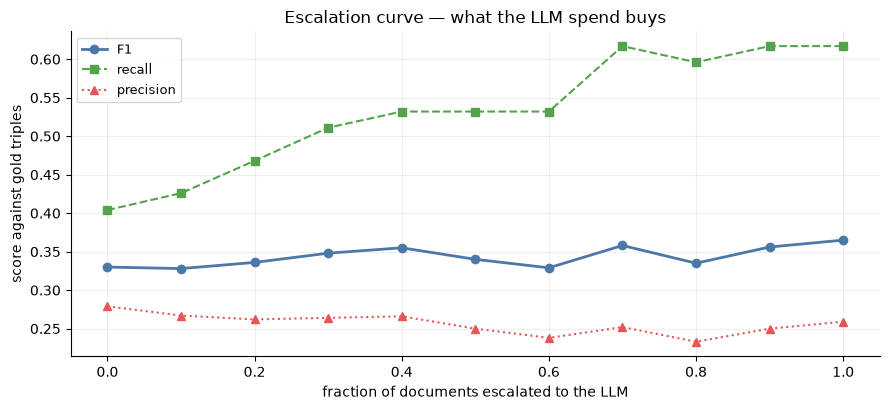

best F1     0.365 at 100% escalation (10 LLM calls, 29/47 gold triples matched)
best recall 0.617 at 70% escalation (7 LLM calls, 29/47 matched)
0%   escalation (pure GLiNER): F1 0.330, 19/47 matched
100% escalation (pure LLM):   F1 0.365, 29/47 matched
first half of the escalation order buys 6 gold triples, second half buys 4


In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(sweep_df.rate, sweep_df.f1, marker="o", lw=2, color="#4C78A8", label="F1")
ax.plot(sweep_df.rate, sweep_df.recall, marker="s", ls="--", color="#54A24B", label="recall")
ax.plot(sweep_df.rate, sweep_df.precision, marker="^", ls=":", color="#E45756", label="precision")
ax.set_xlabel("fraction of documents escalated to the LLM")
ax.set_ylabel("score against gold triples")
ax.set_title("Escalation curve — what the LLM spend buys")
ax.legend(fontsize=9); ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

n_gold = len(GOLD_DOC_FACTS)
best   = sweep_df.loc[sweep_df.f1.idxmax()]
best_r = sweep_df.loc[sweep_df.recall.idxmax()]
print(f"best F1     {best.f1:.3f} at {best.rate:.0%} escalation "
      f"({int(best.llm_calls)} LLM calls, {int(best.matched)}/{n_gold} gold triples matched)")
print(f"best recall {best_r.recall:.3f} at {best_r.rate:.0%} escalation "
      f"({int(best_r.llm_calls)} LLM calls, {int(best_r.matched)}/{n_gold} matched)")
print(f"0%   escalation (pure GLiNER): F1 {sweep_df.iloc[0].f1:.3f}, "
      f"{int(sweep_df.iloc[0].matched)}/{n_gold} matched")
print(f"100% escalation (pure LLM):   F1 {sweep_df.iloc[-1].f1:.3f}, "
      f"{int(sweep_df.iloc[-1].matched)}/{n_gold} matched")
print(f"first half of the escalation order buys "
      f"{int(sweep_df.iloc[5].matched) - int(sweep_df.iloc[0].matched)} gold triples, "
      f"second half buys {int(sweep_df.iloc[-1].matched) - int(sweep_df.iloc[5].matched)}")

The dial is real and it has no knee. F1 goes from 0.330 at pure GLiNER to 0.365 at pure LLM — 0.035 across
the entire sweep, with individual steps as large as 0.023 in the wrong direction — and nothing in the middle
beats both ends. The section was written expecting an interior optimum and there isn't one.

What the curve does show is a saturation point. Recall reaches 29 of 47 gold triples at 70% escalation and
does not move again; the last three LLM calls buy nothing, and the F1 maximum at 100% sits inside the noise
of the point at 70%. If you want an operating point out of this, that is the one — not because the maximum
is there but because the climbing stops there.

Three things bound how hard to read any of it. The eleven points are nested subsets of the same ten
documents scored against the same 47 triples, so adjacent points differ by one or two gold facts: the dip at
80% is a single triple and the F1 wobble between 10% and 60% is noise rather than structure. The escalated
half is unvalidated LLM output — §2 showed that filtering it is free and worth about four points of
precision, which would lift every point with k > 0 and leave the k = 0 point alone. And F1 is the wrong
metric to pick a winner with here: §2 argued that precision is a lower bound because a spurious triple is
usually true-but-unlabelled, so F1 systematically under-rewards the system that produces more. Recall is the
half §2 called trustworthy, and recall is the half that says stop at 70%.

The trigger comes out of this worst. Ranking by relations-per-entity is supposed to front-load the gains:
the first five documents in that order buy 6 gold triples against the second five's 4, which is barely a
gradient, and the single largest jump in the sweep is the *seventh* document in the ranking while the fifth
and sixth buy nothing at all. So this heuristic is not ordering documents by how much the LLM will help
them, and the curve above is a baseline for a better trigger rather than evidence that this one works. A
better one would use GLiNER's own confidence, or the presence of ontology relations that never fired, or a
cheap classifier trained on where the two extractors disagreed.

The shape of the curve is still the answer to "should I use an LLM for extraction", and it is corpus-specific
— which is the point of having a sandbox rather than a rule of thumb. Run it on your own documents and your
own ontology before deciding. Ten documents is not enough to conclude anything about yours.

## 5. Cost and latency

In [18]:
# ClaudeCLI records latency and cost for cached responses too, so these numbers
# survive a re-run against a warm cache instead of collapsing to NaN. The
# document-only snapshot taken in §1 is what this divides by -- `llm`'s own
# counters have the §3 probes folded into them by now.
per_doc_ms = {
    "spaCy trf (closed vocab)": spacy_time / len(DOCUMENTS) * 1000,
    "GLiNER2.5-base":           gliner_time / len(DOCUMENTS) * 1000,
    "Claude Haiku 4.5":         doc_latency_ms,
}
llm_cost_per_doc = doc_cost_usd / max(doc_calls, 1)

cost = pd.DataFrame([
    {"system": k,
     "ms/doc": round(v),
     "$/doc": round(llm_cost_per_doc, 4) if k.startswith("Claude") else 0.0,
     "$/1k docs": round(llm_cost_per_doc * 1000, 2) if k.startswith("Claude") else 0.0,
     "F1": scores[k].f1}
    for k, v in per_doc_ms.items()
]).set_index("system")
display(cost)

print("Caveats worth stating:")
print(f"  - Claude is {per_doc_ms['Claude Haiku 4.5']/per_doc_ms['GLiNER2.5-base']:.1f}x GLiNER and "
      f"{per_doc_ms['Claude Haiku 4.5']/per_doc_ms['spaCy trf (closed vocab)']:.0f}x spaCy per document.")
print(f"  - LLM timing is via the `claude` CLI, which adds subprocess and agent-framing overhead.")
print(f"    The raw API would be faster and cheaper; treat these as an upper bound.")
print(f"  - Cost and latency above are what these calls measured when first made.")
print(f"    This run: {llm.n_calls} live, {llm.n_cached} replayed from cache "
      f"(${llm.total_cost_usd:.4f} billed now, ${llm.observed_cost_usd:.4f} originally); "
      f"{doc_calls} of those are the document extractions in this table, the rest are §3 probes.")
print(f"  - The encoder timings are one wall-clock measurement each: CPU, single process, no batching")
print(f"    beyond batch_size=8. spaCy's includes model warm-up and is the least stable number here.")
print(f"  - A fresh clone has no cache. The first run is live, billed, and will not match these exactly.")

,ms/doc,$/doc,$/1k docs,F1
system,,,,
spaCy trf (closed vocab),65,0.0000,0.00,0.000000
GLiNER2.5-base,837,0.0000,0.00,0.330435
Claude Haiku 4.5,6116,0.0077,7.66,0.364780


Caveats worth stating:
  - Claude is 7.3x GLiNER and 94x spaCy per document.
  - LLM timing is via the `claude` CLI, which adds subprocess and agent-framing overhead.
    The raw API would be faster and cheaper; treat these as an upper bound.
  - Cost and latency above are what these calls measured when first made.
    This run: 0 live, 17 replayed from cache ($0.0000 billed now, $0.0932 originally); 10 of those are the document extractions in this table, the rest are §3 probes.
  - The encoder timings are one wall-clock measurement each: CPU, single process, no batching
    beyond batch_size=8. spaCy's includes model warm-up and is the least stable number here.
  - A fresh clone has no cache. The first run is live, billed, and will not match these exactly.


The absolute numbers are soft — a subprocess CLI is not how anyone runs an LLM at volume. The **ratio** is
the more durable finding, and it is smaller than the folklore: a single-digit multiple of GLiNER per
document, and even that is an upper bound because the raw API would narrow it. Not orders of magnitude. The
exact multiples printed above are worth less than the fact that they are small — both encoder timings are
one wall-clock pass rather than a benchmark, and spaCy's in particular is dominated by warm-up and moves
severalfold between runs of this notebook.

The cost ratio is the structural one. The encoders carry no per-call bill at all, the LLM bills a bit under
$8 per thousand documents, and no amount of tuning closes a gap between zero and non-zero. Whether that
matters depends entirely on volume: for a hundred documents it is a rounding error, and for a memory graph
that re-extracts on every conversation turn it is the whole design.

## 6. What the numbers say

Four findings worth carrying out of this notebook, and one non-finding.

**The "encoder cannot do inference" claim was too strong, and the corrected version is sharper.** GLiNER
emitted the triple for the implied relation, the cross-sentence syllogism and the bridged referent, and
picked the right company when two were on offer. It also emitted one for the negated sentence, where the
answer is nothing — §3 has what that does and does not establish, and the answer is less than it looks.
The real boundary is about arguments rather than inference: a relation can be inferred from context, but an
entity argument has to be anchored somewhere in the text. Notebook 01's wording has been corrected.

**Closed vocabulary is a hard ceiling, not a quality gap.** spaCy is a strong supervised tagger — 0.899 F1
on OntoNotes by its own model card, which is not a number this notebook measured — and it scores zero here.
Not because it is bad: it produced 189 mentions and no relations at all, because 8 of 13 entity types and
all 15 relations are inexpressible in OntoNotes. If your ontology fits inside a supervised tagger's label
set, use the tagger. If it does not, its F1 is irrelevant to you.

**Typed decoding is a real guarantee, not a nicety.** GLiNER's `JointIE` produced zero ontology violations
across the corpus because endpoint types are a decoding constraint. The LLM produced violations that need a
validation pass to catch — cheap to add, and §2 prices it at about four points of precision, free, when you
do.

**Escalation is a dial, and on this corpus it has no knee.** The sweep in §4 goes from 19 matched gold
triples at pure GLiNER to 29 at pure LLM, and recall gets to 29 at 70% escalation and stays there — so the
operating point worth having is a saturation point, not a maximum. The relations-per-entity trigger did not
earn its keep either: the fifth and sixth documents in its ranking buy nothing and the seventh buys four,
which is not what a ranking by expected benefit looks like. Measure the curve on your own data before
choosing an architecture; the thing to notice here is that it did not come out the way §4 expected.

The non-finding: **this corpus is ten documents and 47 gold triples.** Every number here has wide error bars
and a difference of a point or two is noise — the F1 wobble across the middle of the escalation curve is the
clearest example. The gap between the encoder and the LLM is larger than that, 19 against 29 gold triples
matched, but it is still ten facts on one corpus with one ontology, and §0's cache note explains why even
those ten move between runs. What the notebook establishes is the *method* — an interchangeable extractor
interface, a stated matching policy, one scoreboard — not a verdict about GLiNER versus Claude in general.

In [19]:
# Key the extra columns by system name -- comparison_table() sorts by F1, so
# positional assignment silently attaches each value to the wrong row.
by_system = {
    "spaCy trf (closed vocab)": spacy_graphs,
    "GLiNER2.5-base": gliner_graphs,
    "Claude Haiku 4.5": llm_graphs,
}
final = comparison_table(scores).copy()
final["doc-local edges"] = [sum(len(g.edges) for g in by_system[s]) for s in final.index]
final["ontology violations"] = [
    sum(len(g.validate(kgx.BUSINESS_NEWS)) for g in by_system[s]) for s in final.index
]
display(final)

# `predicted` and `doc-local edges` count different things and disagree about who is
# louder, so account for the gap between them rather than leaving it to be misread.
for name in ("GLiNER2.5-base", "Claude Haiku 4.5"):
    edges = systems[name]["graph"].edges
    within = sum(e.support - e.n_docs for e in edges)
    across = sum(e.n_docs - 1 for e in edges)
    print(f"{name}: {sum(len(g.edges) for g in by_system[name])} doc-local edges -> "
          f"{len(edges)} canonical  ({within} within-document repeats, {across} cross-document)")

print(f"\nLLM cost of this comparison: ${llm.observed_cost_usd:.4f} across {llm.n_observed} calls "
      f"({doc_calls} documents + {llm.n_observed - doc_calls} probes, "
      f"${llm.observed_cost_usd/max(llm.n_observed,1):.5f} each).")
print(f"Billed on this run: ${llm.total_cost_usd:.4f} "
      f"— {llm.n_calls} live, {llm.n_cached} replayed from cache.")
print(f"cache: {len(list(llm.cache_dir.glob('*.json')))} responses in {llm.cache_dir}")
print("delete that directory to force genuine re-runs.")

,policy,predicted,gold,matched,precision,recall,f1,doc-local edges,ontology violations
system,,,,,,,,,
Claude Haiku 4.5,normalised + aliases,112,47,29,0.259,0.617,0.365,140,16
GLiNER2.5-base,normalised + aliases,68,47,19,0.279,0.404,0.330,170,0
spaCy trf (closed vocab),normalised + aliases,0,47,0,0.000,0.000,0.000,0,0


GLiNER2.5-base: 170 doc-local edges -> 68 canonical  (89 within-document repeats, 13 cross-document)
Claude Haiku 4.5: 140 doc-local edges -> 112 canonical  (0 within-document repeats, 28 cross-document)

LLM cost of this comparison: $0.0932 across 17 calls (10 documents + 7 probes, $0.00548 each).
Billed on this run: $0.0000 — 0 live, 17 replayed from cache.
cache: 36 responses in output/llm_cache
delete that directory to force genuine re-runs.


Two of those columns count different things and they disagree about who is louder. **predicted** is canonical
triples: what survives resolution and edge collapse, and what precision is computed against. **doc-local
edges** is what came out of the extractor before any merging. GLiNER's 170 collapse to 68 almost entirely
inside single documents — 89 of the 102 it loses are the same relation restated between different mentions
of the same pair in one document, and only 13 are the same edge recurring across documents. The LLM already
deduplicates within a document, so every one of its losses is cross-document. When §2 says Claude emitted 112
triples and GLiNER 68, it means the canonical column; the raw column points the other way, and the gap is a
difference between the two architectures rather than a bookkeeping artefact.

## Where to take it

**Better escalation triggers.** The relations-per-entity heuristic in §4 ranks documents badly: the biggest
single gain in the sweep comes from the seventh document in its order. Use GLiNER's own confidence, or the
count of ontology relations that never fired, or train a cheap classifier on the documents where the two
extractors disagreed. Add a shuffled-order control while you are at it: sweeping a few random escalation
orders and reporting the mean and range would separate the trigger's contribution from the fact that
escalating anything helps at all, and every graph it needs is already computed here.

**More gold.** 47 triples is enough to be instructive and not enough to be conclusive. Hand-annotating a few
hundred, or having two models annotate and adjudicating the disagreements, changes what this notebook can
claim. Pooled judging over the union of what all systems produced would fix the precision lower-bound
problem in §3 at the same time.

**Ontology-as-prompt is under-explored.** The LLM gets the ontology as a wall of text. Few-shot examples,
per-relation instructions, or a two-pass approach (entities, then relations between known entities) would
each likely move the number, and none of them are tried here. The violation count in §1 suggests the
head/tail constraint section of that prompt is not carrying its weight.

**Distillation.** [Notebook 06](06_finetuning_distillation.ipynb) takes the LLM output from this notebook as
training labels and fine-tunes GLiNER on them — the "LLM as teacher" path from `docs/LANDSCAPE.md`, and the
strongest cost/quality point in the whole survey if it works.